In this assignment, you will implement Sequence-to-Sequence (Seq2Seq) workflow for text summarization using the CNN/DailyMail dataset.    

1) Establish Baselines: Quantify the 'Context Bottleneck' using Lead-3 heuristics.

2) Fine-Tuning with Attention: Adapt a pre-trained BART or T5 model to the news domain using the Trainer API.

3) Interpretability Study: Visualize Attention Heatmaps to prove that the model can 'attend' to relevant facts regardless of their position in the text

This assignment builds on Module 4 (RNNs & LSTMs) and emphasizes the transition from manual architectural builds to industry-standard transfer learning

### Bridging the Gap: From Keras to Hugging Face

In Week 4, you built models by "wiring" layers together manually using Keras. You defined the input, hidden layers, and output, and then you told the model how to learn using `.compile()` and `.fit()`.

This week, we are moving to **Transfer Learning** using the Hugging Face `Trainer` API. This can feel like a jump in complexity because the "training loop" is no longer visible—it is abstracted away. Use the mapping below to translate what you know (Keras) to what you are about to use (Hugging Face).


* **The Model:** In Keras, you built the model step-by-step. In Hugging Face, you download a pretrained model (`AutoModelForSeq2SeqLM.from_pretrained`)

* **Configuration:** Instead of `model.compile()`, you set hyperparameters in a config object called `Seq2SeqTrainingArguments`

* **The Loop:** Instead of `model.fit()`, you initialize a `Seq2SeqTrainer` object and call `trainer.train()`. The Trainer automatically handles dynamic padding, learning rate decay, and GPU optimization.

## Part 1: Preprocessing and Dataset Preparation (20 Points)



####

Use the code below to download the CNN/DailyMail dataset (3.0.0)
Standarized Samplling of 2,000 training records, 500 validation and 500 test records

Initialize a pre-trained tokenizer (e.g. AutoTokenizer) matching your selected Transformer model (Bart or T5)

Convert the processed records into a format ready for a Keras-integrated data loader




In [61]:
## Student Code Required ##
 # Instruction: Initialize the tokenizer and determine the optimal sequence
 # lengths for articles vs. highlights.
 # You can enforce a 2,000-sample training limit to assist with execution

# ==================== Part 1: Dataset & Tokenization ====================
from transformers import AutoTokenizer

model_checkpoint = "facebook/bart-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
input_max_len = 512
label_max_len = 128

def preprocess_function(examples):
    # Category A Blanks: Define truncation and padding strategies
    model_inputs = tokenizer(examples["article"],
                             max_length=input_max_len, # Choose 512 for articles
                             truncation=True,
                             padding="max_length")

    # Updated: as_target_tokenizer was deprecated
    labels = tokenizer(text_target = examples["highlights"],
                        max_length=label_max_len, # Choose 128 for summaries
                        truncation=True,
                        padding="max_length")

    # Replace the pad_token_id with -100 in the labels tensor
    model_inputs["labels"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label] 
        for label in labels["input_ids"]
    ]
    return model_inputs

In [62]:
from datasets import load_dataset

raw_dataset = load_dataset("cnn_dailymail", "3.0.0")

In [63]:
# Student Task: Map the preprocessing function to the standardized subsets
# (2000 train / 500 val / 500 test)
train = raw_dataset["train"].shuffle(seed=42).select(range(2000))
val = raw_dataset["validation"].shuffle(seed=42).select(range(500))
test = raw_dataset["test"].shuffle(seed=42).select(range(500))

train_tokenized = train.map(preprocess_function, batched=True)
val_tokenized = val.map(preprocess_function, batched=True)
test_tokenized = test.map(preprocess_function, batched=True)

Map: 100%|██████████| 500/500 [00:00<00:00, 2846.44 examples/s]


Exercise:

1.   In the code, we set the max sequence length for articles to 512. Why don't we set it to 2,000 to capture the whole article? Explain how the Self-Attention mechanism's memory requirement scales with sequence length (Hint: is it linear or quadratic?).

**The**

2.   Discuss how excessive truncation might lead to a loss of the 'Lead-3' information



## Part 2: Baseline Performance Benchmarking (20 Points)

In [64]:
## Student Code Required ##
 # Instruction: Implement the Lead-3 heuristic.
 # Then, evaluate both Lead-3 and a Zero-Shot BART model to
 # establish a quantitative 'floor' for performance.

import nltk
import torch

#download required data for sentence tokenizing
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 845.15it/s, Materializing param=model.shared.weight]                                  


BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 768, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_n

In [65]:
def get_lead_3_baseline(text):
    """
    Extracts the first 3 sentences.
    """
    try:
        sentences = nltk.sent_tokenize(text)
    except:
        # Fallback if NLTK fails or text is empty
        sentences = text.split(".")
        
    return " ".join(sentences[:3])

def get_zeroshot_summary(text, model, tokenizer):
    """
    Generates a summary using the model manually.
    """
    # 1. Tokenize and move to device
    inputs = tokenizer(text, return_tensors="pt", max_length=input_max_len, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 2. Generate Summary IDs
    # We use 'no_grad' to save memory since we aren't training
    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=128,
            min_length=30,
            early_stopping=True
        )
        
    # 3. Decode IDs to Text
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [66]:
from tqdm import tqdm
import evaluate

rouge = evaluate.load('rouge')

# Lists to store results
lead_3_preds = []
zero_shot_preds = []
references = []

# Iterate through the val dataset
for i, example in enumerate(tqdm(val)):
    article = example["article"]
    highlights = example["highlights"]
    
    # A. Generate Lead-3
    lead_3_preds.append(get_lead_3_baseline(article))
    
    # B. Generate Zero-Shot (DistilBART)
    zero_shot_preds.append(get_zeroshot_summary(article, model, tokenizer))
    
    # C. Store Reference
    references.append(highlights)

# --- Calculation ---

print("\nComputing ROUGE Scores...")

# 1. Calculate Lead-3 Score
lead_3_results = rouge.compute(
    predictions=lead_3_preds, 
    references=references
)
print(f"Lead-3 ROUGE-L: {lead_3_results['rougeL']:.4f}")

# 2. Calculate Zero-Shot Score
zero_shot_results = rouge.compute(
    predictions=zero_shot_preds, 
    references=references
)
print(f"Zero-Shot ROUGE-L: {zero_shot_results['rougeL']:.4f}")

100%|██████████| 500/500 [06:43<00:00,  1.24it/s]



Computing ROUGE Scores...
Lead-3 ROUGE-L: 0.2591
Zero-Shot ROUGE-L: 0.2510


Exercise:

1.   Explain the 'Context Bottleneck.' Why do standard Seq2Seq models struggle to summarize articles when the most relevant information is buried in the middle of the text rather than the beginning?

## Part 3: Transformer Fine-Tuning with Attention (40 Points)

In [67]:
## Student Code Required ##
 # Instruction: Configure the Seq2SeqTrainingArguments.
 # You must select the learning rate and epoch count that balances
 # convergence with the risk of catastrophic forgetting.

# ==================== Part 3: Fine-Tuning ====================
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import torch


training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    learning_rate=5e-5,        # Hint: 5e-5 is standard for BART
    num_train_epochs=10,     # Hint: 3 to 5 is sufficient
    per_device_train_batch_size=8,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
    max_length=input_max_len
)

# Category B Scaffold: Initialization of the Trainer API
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    data_collator=data_collator
)

# Train the model
trainer.train()

Step,Training Loss
500,2.294577
1000,1.660784
1500,1.295459
2000,1.055393
2500,0.916512


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]


TrainOutput(global_step=2500, training_loss=1.4445451171875, metrics={'train_runtime': 201.8663, 'train_samples_per_second': 99.075, 'train_steps_per_second': 12.384, 'total_flos': 6097364582400000.0, 'train_loss': 1.4445451171875, 'epoch': 10.0})

Exercise:

1.   How does the predict_with_generate argument differ from standard training?

2.   We configured the model to use **Beam Search** for generating summaries. Contrast Beam Search with **Greedy Search**. Why is Greedy Search highly likely to fail in a sequence-to-sequence summarization task, and how does Beam Search fix this?

## Part 4: Model Evaluation & Interpretability (20 points)

In [68]:
## Student Code Required ##
 # Instruction: Generate a comparison table of ROUGE scores.
 # Then, execute the Heatmap visualization for ONE article and
 # identify the 'Alignment' between summary tokens and input tokens


 # ==================== Part 4: Attention Visualization ====================
# Student Task: Use aggregate_cross_attention() to visualize weights.


# Qualitative Analysis Blank:
# "In my heatmap, when the model generated the word '____', it was
# specifically attending to the input tokens '____' and '____'."

In [ ]:
import pandas as pd
import numpy as np


print("Generating predictions with the fine-tuned model...")
predictions = trainer.predict(val_tokenized)

# Get just the prediction matrices
preds = np.array(predictions.predictions)

"""# If the model returned raw logits (3D array) instead of token IDs, 
# grab the most likely token ID using argmax.
if len(preds.shape) == 3:
    preds = np.argmax(preds, axis=-1)

# Replace -100 with the actual pad_token_id
preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
labels = np.where(predictions.label_ids != -100, predictions.label_ids, tokenizer.pad_token_id)
"""
# Decode the cleaned predictions and labels
decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(predictions.label_ids, skip_special_tokens=True)

# 3. Calculate Fine-Tuned ROUGE Scores
fine_tuned_results = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

# 4. Generate the Comparison Table
# (Assuming lead_3_results and zero_shot_results variables are still in your memory from Part 2)
data = {
    "Model / Heuristic": ["Lead-3 Baseline", "Zero-Shot bart-base", "Fine-Tuned bart-base"],
    "ROUGE-1": [lead_3_results['rouge1'], zero_shot_results['rouge1'], fine_tuned_results['rouge1']], # Replace with your actual previous R-1 if needed
    "ROUGE-L": [lead_3_results['rouge1'], zero_shot_results['rougeL'], fine_tuned_results['rougeL']]
}

df_scores = pd.DataFrame(data)
print("\n--- Final ROUGE Score Comparison ---")
print(df_scores.to_string(index=False))

Generating predictions with the fine-tuned model...


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def aggregate_cross_attention(model, tokenizer, text, device="cuda"):
    """
    Runs a forward pass and extracts cross-attention weights for visualization.
    """
    model.eval()
    
    # --- THE FIX: Disable SDPA and force eager attention calculation ---
    # This forces the model to use the traditional math that saves the weights
    model.config._attn_implementation = "eager"
    model.config.output_attentions = True
    
    # Tokenize input
    inputs = tokenizer(text, return_tensors="pt", max_length=input_max_len, truncation=True)
    input_ids = inputs["input_ids"].to(device)
    
    # Generate summary and return attentions
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_length=50,
            output_attentions=True, 
            return_dict_in_generate=True,
            early_stopping=True
        )
    
    # Extract generated tokens
    generated_ids = outputs.sequences[0]
    generated_tokens = tokenizer.convert_ids_to_tokens(generated_ids, skip_special_tokens=False)
    input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0], skip_special_tokens=False)
    
    seq_len = len(generated_tokens) - 1 
    attention_matrix = torch.zeros(seq_len, len(input_tokens))
    
    for step in range(seq_len):
        last_layer_attn = outputs.cross_attentions[step][-1] 
        avg_head_attn = last_layer_attn[0].mean(dim=0).squeeze(0)
        attention_matrix[step] = avg_head_attn.cpu()
        
    return attention_matrix.numpy(), input_tokens, generated_tokens[1:]

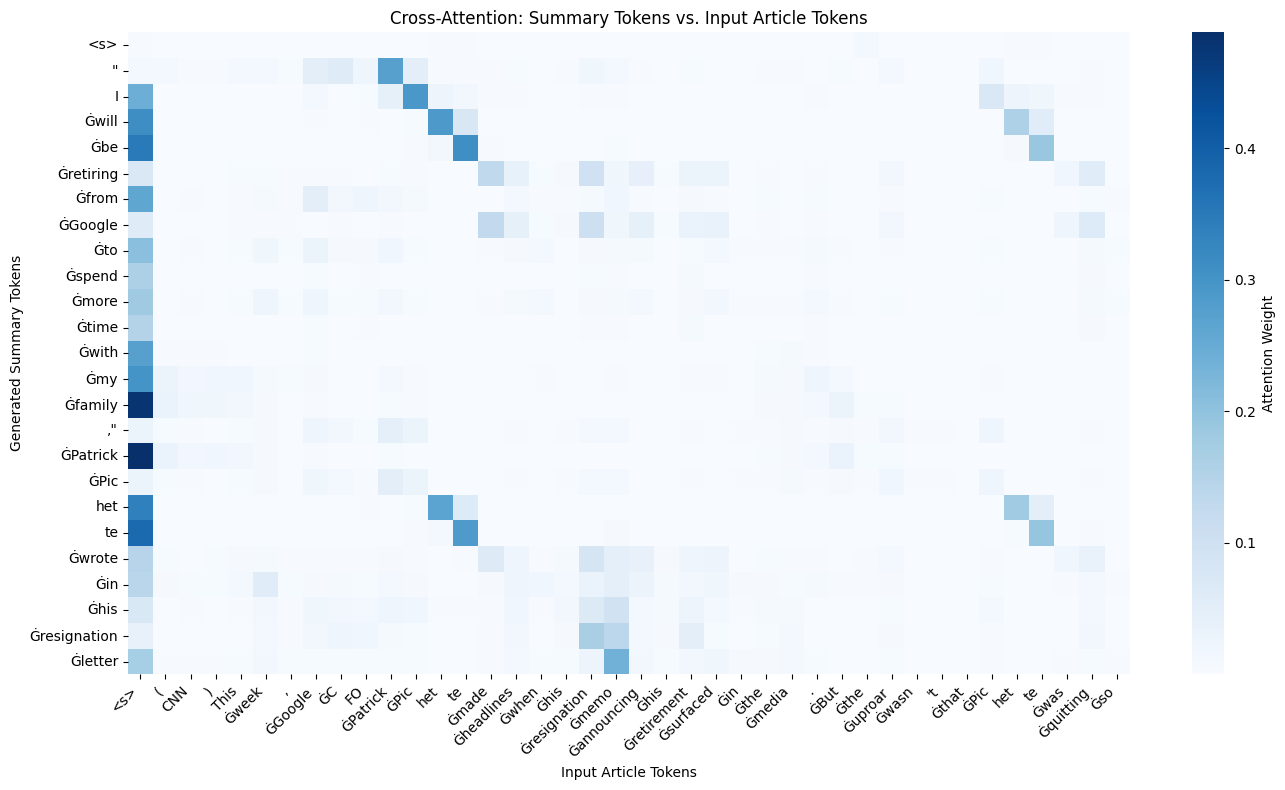

In [74]:
# ==================== Part 4: Attention Visualization ====================

# 1. Select ONE article from your test set
sample_article = raw_dataset["validation"]["article"][100]

# 2. Get the attention matrix and tokens
attention_weights, x_tokens, y_tokens = aggregate_cross_attention(model, tokenizer, sample_article, device)

# 3. Plot the Heatmap
# We limit to the first 25 generated tokens and first 40 input tokens to keep the chart readable
plt.figure(figsize=(14, 8))
sns.heatmap(
    attention_weights[:25, :40], 
    xticklabels=x_tokens[:40], 
    yticklabels=y_tokens[:25], 
    cmap="Blues", 
    cbar_kws={'label': 'Attention Weight'}
)
plt.title("Cross-Attention: Summary Tokens vs. Input Article Tokens")
plt.xlabel("Input Article Tokens")
plt.ylabel("Generated Summary Tokens")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Exercise:

**1. The Mechanism:**
Describe how the Attention Mechanism you visualized allows the decoder to "bypass" the bottleneck of a single fixed context vector used in standard RNNs.

**2. Success Verification:**
In your heatmap above, identify a specific word in the summary that strongly attends to a relevant word in the source text. (e.g., "The summary word 'Apple' attended strongly to 'Cupertino' in the source").

---

**It is easy to find examples where the model works. As a Data Scientist, your job is to find where it breaks.**

**Task: Failure Mode Analysis**
Run the visualization code above for a few different samples (change the index `i`) until you find an instance of **Attention Failure** or **Hallucination**.

**Analysis Prompt:**
Locate a summary where the model generated a word that was **not** supported by the source text, or where it missed a key fact.
* **The Hallucination:** What word did the model generate that wasn't in the source?
* **The Heatmap:** Look at the attention column for that specific hallucinated token.
    * Did it attend to an irrelevant word (Misguided Attention)?
    * Was the attention "scattered" (uniform faint weight across all words)?
* **Implication:** Discuss what this failure implies for using such models in high-stakes fields like Financial News or Medical Summarization.
